In [ ]:
!pip install --force-reinstall git+https://github.com/yhhc2/IsoRanker.git

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
# Import functions from the package
from IsoRanker import (
    filter_based_on_counts,
    apply_hypothesis_test,
    calculate_z_score,
    NMD_test_statistic,
    Noncyclo_Expression_Outlier_LOE,
    Noncyclo_Expression_Outlier_GOE,
    Cyclo_Expression_Outlier_GOE,
    NMD_rare_steady_state_transcript,
    Noncyclo_Allelic_Imbalance,
    Cyclo_Allelic_Imbalance,
    calculate_ranks_for_sample,
    create_expression_matrix,
    create_long_format,
    process_hypothesis_test,
    update_files_with_haplotype_info,
    merge_tsvs_by_keyword, 
    process_vep_vcf, 
    merge_haplotype_data, 
    process_phenotype_data
)

### Downsample read_stat and define subsets


In [ ]:
input_file = "/mmfs1/gscratch/stergachislab/asedeno/data/github/IsoSeq_smk/results/collapse/collapsed.read_stat.txt" 
read_limits = [50_000, 100_000, 250_000, 500_000, 1_000_000, 2_000_000, 3_000_000, 4_000_000]  # Different downsampling levels

# Read the file
df = pd.read_csv(input_file, sep="\t", dtype=str)

# Extract sample name (everything before "_m")
df["sample"] = df["id"].str.extract(r"(^.*)_m")

# Function to downsample per sample
def downsample_group(group, max_reads):
    if len(group) > max_reads:
        return group.sample(n=max_reads, random_state=42)
    return group

# Generate downsampled files for each read limit
for max_reads in read_limits:
    downsampled_df = df.groupby("sample", group_keys=False).apply(downsample_group, max_reads=max_reads)
    downsampled_df.drop(columns=["sample"], inplace=True)
    
    output_file = f"downsampled_{max_reads / 1_000_000:.2f}M.txt"
    downsampled_df.to_csv(output_file, sep="\t", index=False)
    print(f"Downsampled file saved as {output_file}")



# Patient subsets
patient_subsets = {
    "patients_31": {"UDN633333", "UDN212054", "UDN215640", "UDN052264", "BCH_1877-01", "BCH_2410-01", "BCH_2275-01", "BCH_2401-01", "BCH_2443-01", "BCH_0252-01", "BCH_1199-01", "BCH_1986-01", "BCH_310-01", "UDN318336", "UDN374570", "UDN687128", "UDN121217", "UDN178694", "UDN827597", "UDN355246", "UDN966087", "UDN305049", "UDN204349", "UDN359892", "UDN010451", "UDN262407", "UDN924176", "UDN310876", "UDN860070", "UDN666440", "UDN353099"},
    "patients_26": {"UDN633333", "UDN212054", "UDN215640", "UDN052264", "BCH_2410-01", "BCH_2275-01", "BCH_2401-01", "BCH_0252-01", "BCH_1199-01", "BCH_1986-01", "BCH_310-01", "UDN318336", "UDN374570", "UDN687128", "UDN121217", "UDN178694", "UDN827597", "UDN355246", "UDN966087", "UDN204349", "UDN359892", "UDN010451", "UDN262407", "UDN924176", "UDN310876", "UDN860070"},
    "patients_21": {"UDN633333", "UDN212054", "UDN215640", "UDN052264", "BCH_2410-01", "BCH_2275-01", "BCH_2401-01", "BCH_0252-01", "BCH_1199-01", "BCH_1986-01", "UDN318336", "UDN374570", "UDN687128", "UDN121217", "UDN178694", "UDN966087", "UDN204349", "UDN359892", "UDN010451", "UDN262407", "UDN924176"},
    "patients_16": {"UDN633333", "UDN212054", "UDN215640", "UDN052264", "BCH_2410-01", "BCH_2275-01", "BCH_1199-01", "BCH_1986-01", "UDN318336", "UDN374570", "UDN687128", "UDN204349", "UDN359892", "UDN010451", "UDN262407", "UDN924176"},
    "patients_11": {"UDN633333", "UDN212054", "UDN215640", "UDN052264", "BCH_2401-01", "BCH_0252-01", "BCH_1199-01", "BCH_1986-01", "UDN318336", "UDN374570", "UDN687128"},
    "patients_6": {"UDN633333", "UDN212054", "UDN215640", "UDN052264", "BCH_2401-01", "UDN687128"},
    "patients_4": {"UDN633333", "UDN212054", "UDN215640", "UDN687128"}
}


# List of read_stat_path files to process
read_stat_paths = [
    "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Jupyter/Ranking_change_with_different_read_counts/4.14.25/downsampled_0.05M.txt",
    "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Jupyter/Ranking_change_with_different_read_counts/4.14.25/downsampled_0.10M.txt",
    "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Jupyter/Ranking_change_with_different_read_counts/4.14.25/downsampled_0.25M.txt",
    "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Jupyter/Ranking_change_with_different_read_counts/4.14.25/downsampled_0.50M.txt",
    "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Jupyter/Ranking_change_with_different_read_counts/4.14.25/downsampled_1.00M.txt",
    "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Jupyter/Ranking_change_with_different_read_counts/4.14.25/downsampled_2.00M.txt",
    "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Jupyter/Ranking_change_with_different_read_counts/4.14.25/downsampled_3.00M.txt",
    "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Jupyter/Ranking_change_with_different_read_counts/4.14.25/downsampled_4.00M.txt",
    "/mmfs1/gscratch/stergachislab/asedeno/data/github/IsoSeq_smk/results/collapse/collapsed.read_stat.txt"
    
]



### Generate IsoRanker results for each downsampling and subset

In [ ]:
for read_stat_path in read_stat_paths:
    
    # Define input files

    base_filename = os.path.basename(read_stat_path).replace(".txt", "").replace(".gz", "")
    
    # Provides every single read, which sample each read came from, and the isoform asssociated with each read
    #read_stat_path = "/mmfs1/gscratch/stergachislab/asedeno/data/github/IsoSeq_smk/results/collapse/collapsed.read_stat.txt"
    
    # Assigns samples to patients, cyclo/non-cyclo, and haplotypes
    sample_info_with_haplotype_location_path = "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/Jupyter/Add_genetic_and_haplotype/3.11.25/input/Sample_info.tsv"
    
    # Provides pigeon annotation for isoforms
    classification_path = "/mmfs1/gscratch/stergachislab/asedeno/data/github/IsoSeq_smk/results/pigeon/pigeon_classification.txt"
    classification_data = pd.read_csv(classification_path, sep="\t")
    
    # Provide omim information for genes
    genemap_path = "/mmfs1/gscratch/stergachislab/yhhc/projects/IsoRanker_testing/genemap2.txt"
    genemap = pd.read_csv(genemap_path, sep='\t', skiprows=3) # Read the file, skipping the first 3 rows
    genemap = genemap[genemap['Approved Gene Symbol'].notnull()]
    
    # Reference file for SRSF6 QC pileup
    reference_fasta_path = "/gscratch/stergachislab/assemblies/simple-names/hg38.fa"

    output_dir = "."
    update_files_with_haplotype_info(sample_info_with_haplotype_location_path, read_stat_path, output_dir)
    
    # Define input files
    
    # Provides every single read, which sample each read came from, and the isoform asssociated with each read
    read_stat_path = "updated_read_stats.txt.gz"
    sample_info_path = "updated_sample_info.tsv.gz"
    
    # Assigns samples to patients, cyclo/non-cyclo, and haplotypes
    sample_info = pd.read_csv(sample_info_path, sep="\t")
    
    # Create the expression matrix and save it to a file
    expression_matrix = create_expression_matrix(read_stat_path, output_file="expression_matrix.tsv.gz")
    
    # Generate the long-format dataFrame and adding cyclo/noncyclo as well as haplotype labels and calculate TPM
    long_format_df = create_long_format(expression_matrix, sample_info)

    # Select only the 'isoform' and 'associated_gene' columns from classification_data
    classification_subset = classification_data[['isoform', 'associated_gene']]
    # Merge the classification subset with the long_format_df
    long_format_annotated = long_format_df.merge(
        classification_subset,
        left_on="Isoform",   # Match isoform IDs in long_format_df
        right_on="isoform",  # Match isoform IDs in classification_subset
        how="left"           # Keep all rows from long_format_df, even if there's no match in classification_subset
    ).drop(columns=["isoform"])  # Drop redundant 'isoform' column from classification_subset
    
    long_format_annotated.to_csv("long_format_annotated.tsv.gz", index=False, compression = "gzip", sep="\t")
    

    for subset_name, patient_ids in patient_subsets.items():

        print(f"Processing subset: {subset_name}", flush=True)
        subset_output_dir = os.path.join("results", subset_name, base_filename)
        os.makedirs(subset_output_dir, exist_ok=True)

        subset_long_format = long_format_annotated[long_format_annotated["Sample"].isin(patient_ids)]

        # Calculate for all hypothesis tests
        test_stat_funcs = [
            ("NMD", NMD_test_statistic),
            ("Noncyclo_LOE", Noncyclo_Expression_Outlier_LOE),
            ("Noncyclo_GOE", Noncyclo_Expression_Outlier_GOE),
            ("Cyclo_GOE", Cyclo_Expression_Outlier_GOE),
            ("NMD_rare_steady_state_transcript", NMD_rare_steady_state_transcript),
            ("Nonyclo_Allelic_Imbalance", Noncyclo_Allelic_Imbalance),
            ("Cyclo_Allelic_Imbalance", Cyclo_Allelic_Imbalance)
        ]
        
        # Store full results to generate lookup table
        full_ranked_gene_data = []

        genes_of_interest = {"DND1_HARS1", "HARS1", "SET", "MFN2", "VTA1"}

        #Gene level
        for test_name, test_func in test_stat_funcs:
            print(f"Processing test statistic: {test_name}",  flush=True)
    
            # Apply the process_hypothesis_test function
            ranked_data = process_hypothesis_test(
                filtered_data=subset_long_format, 
                group_col='Isoform', 
                test_statistic_func=test_func, 
                gene_group_col='associated_gene', 
                gene_level=True, 
                bin_proportion=0.01, 
                filter_before_ranking=True, 
                filter_count_threshold=10)
    
            # Filter for genes of interest
            filtered_ranked_data = ranked_data[ranked_data['associated_gene'].isin(genes_of_interest)]
    
            # Add OMIM data to genes
            filtered_ranked_data = filtered_ranked_data.merge(
                genemap[['Approved Gene Symbol', 'Phenotypes']],  # Select relevant columns from genemap
                how='left',  # Perform a left join to keep all rows from filtered_ranked_data
                left_on='associated_gene',  # Column in filtered_ranked_data to join on
                right_on='Approved Gene Symbol'  # Column in genemap to join on
            )
            # Drop the 'Approved Gene Name' column if it is no longer needed
            filtered_ranked_data = filtered_ranked_data.drop(columns=['Approved Gene Symbol'])
    
            # Save the results to a tsv file
            output_dir = subset_output_dir
            output_file = os.path.join(output_dir, f"{test_name}_gene_top_ranked_data_{base_filename}.tsv.gz")
            filtered_ranked_data.to_csv(output_file, index=False, compression = "gzip", sep="\t")
            print(f"Results saved to {output_file}", flush=True)
    

        test_stat_funcs = [
            ("NMD", NMD_test_statistic),
            ("Noncyclo_LOE", Noncyclo_Expression_Outlier_LOE),
            ("Noncyclo_GOE", Noncyclo_Expression_Outlier_GOE),
            ("Cyclo_GOE", Cyclo_Expression_Outlier_GOE)
        ]
        
        #Isoform level
        for test_name, test_func in test_stat_funcs:
            print(f"Processing test statistic: {test_name}")
    
            # Apply the process_hypothesis_test function
            ranked_data = process_hypothesis_test(
                filtered_data=subset_long_format, 
                group_col='Isoform', 
                test_statistic_func=test_func, 
                gene_group_col='associated_gene', 
                gene_level=False, 
                bin_proportion=0.01, 
                filter_before_ranking=True, 
                filter_count_threshold=10)
    
            # Filter for genes of interest
            filtered_ranked_data = ranked_data[ranked_data['associated_gene'].isin(genes_of_interest)]
    
            # Add OMIM data to genes
            filtered_ranked_data = filtered_ranked_data.merge(
                genemap[['Approved Gene Symbol', 'Phenotypes']],  # Select relevant columns from genemap
                how='left',  # Perform a left join to keep all rows from filtered_ranked_data
                left_on='associated_gene',  # Column in filtered_ranked_data to join on
                right_on='Approved Gene Symbol'  # Column in genemap to join on
            )
            # Drop the 'Approved Gene Name' column if it is no longer needed
            filtered_ranked_data = filtered_ranked_data.drop(columns=['Approved Gene Symbol'])
    
            # Save the results to a tsv file
            output_dir = subset_output_dir
            output_file = os.path.join(output_dir, f"{test_name}_isoform_top_ranked_data_{base_filename}.tsv.gz")
            filtered_ranked_data.to_csv(output_file, index=False, compression = "gzip", sep="\t")
            print(f"Results saved to {output_file}",  flush=True)
        

        # Isoform
        directory = subset_output_dir
        keyword = "isoform" 
        output_tsv = os.path.join(subset_output_dir, f"merged_ranked_{keyword}.tsv.gz")
        merge_tsvs_by_keyword(directory, keyword, output_tsv)

        # Gene
        directory = subset_output_dir
        keyword = "gene"
        output_tsv = os.path.join(subset_output_dir, f"merged_ranked_{keyword}.tsv.gz")
        merge_tsvs_by_keyword(directory, keyword, output_tsv)


        # Load the merged gene-level results
        file_path = os.path.join(subset_output_dir, f"merged_ranked_gene.tsv.gz")  # Update with the actual file path
        df = pd.read_csv(file_path, sep="\t", compression = "gzip")

        # Define filtering conditions dynamically
        filter_conditions = " | ".join([
            "(Sample == 'UDN212054') & (associated_gene == 'HARS1')",
            "(Sample == 'UDN212054') & (associated_gene == 'DND1_HARS1')",
            "(Sample == 'UDN633333') & (associated_gene == 'MFN2')",
            "(Sample == 'UDN687128') & (associated_gene == 'VTA1')",
            "(Sample == 'UDN215640') & (associated_gene == 'SET')"
        ])

        # Apply filtering using eval()
        filtered_df = df[df.eval(filter_conditions)]

        # Save the filtered results to a tsv file
        output_file = os.path.join(subset_output_dir, f"filtered_merged_ranked_gene.tsv")
        filtered_df.to_csv(output_file, index=False, sep="\t")

        print(f"Filtered results saved to {output_file}", flush=True)

        import pandas as pd

        # Load the merged gene-level results
        file_path = os.path.join(subset_output_dir, f"merged_ranked_isoform.tsv.gz")  # Update with the actual file path
        df = pd.read_csv(file_path, sep="\t", compression="gzip")

        # Define filtering conditions dynamically
        filter_conditions = " | ".join([
            "(Sample == 'UDN212054') & (associated_gene == 'HARS1')",
            "(Sample == 'UDN212054') & (associated_gene == 'DND1_HARS1')",
            "(Sample == 'UDN633333') & (associated_gene == 'MFN2')",
            "(Sample == 'UDN687128') & (associated_gene == 'VTA1')",
            "(Sample == 'UDN215640') & (associated_gene == 'SET')"
        ])

        # Apply filtering using eval()
        filtered_df = df[df.eval(filter_conditions)]

        # Save the filtered results to a tsv file
        output_file = os.path.join(subset_output_dir, f"filtered_merged_ranked_isoform.tsv")
        filtered_df.to_csv(output_file, index=False, sep="\t")

        print(f"Filtered results saved to {output_file}", flush=True)


### Create summary matrices for each gene-sample combination

##### - Columns are the patient subsets
##### - Rows are the downsamplings
##### - Cells contain the rank

In [ ]:
###################################
# Generating summary matrices for gene-level. 99.5 percentile
###################################

import pandas as pd
import os
import re

# Base directory where all filtered_merged_ranked_gene.tsv files are located
base_dir = "results"

# Patient subsets (columns in order)
subset_order = [
    "patients_31", "patients_26", "patients_21", 
    "patients_16", "patients_11", "patients_6", "patients_4"
]

# Read depth levels (rows in order)
read_stat_order = [
    "downsampled_0.05M", "downsampled_0.10M", "downsampled_0.25M", 
    "downsampled_0.50M", "downsampled_1.00M", "downsampled_2.00M", 
    "downsampled_3.00M", "downsampled_4.00M", "collapsed.read_stat"
]

# Keywords for identifying source types
keywords = sorted([
    "NMD_rare_steady_state_transcript",
    "Nonyclo_Allelic_Imbalance",
    "Cyclo_Allelic_Imbalance",
    "Noncyclo_GOE",
    "Noncyclo_LOE",
    "Cyclo_GOE",
    "NMD"
], key=len, reverse=True)

# Function to extract Source_Type from Source_File
def extract_source_type(source_file):
    for keyword in keywords:
        if keyword in source_file:
            return keyword
    return "Unknown"

# Collect all data
all_data = []

for root, dirs, files in os.walk(base_dir):
    for file in files:
        if file == "filtered_merged_ranked_gene.tsv":
            file_path = os.path.join(root, file)

            # Extract patient subset and read_stat_path from folder structure
            match = re.match(r"results/([^/]+)/([^/]+)/filtered_merged_ranked_gene.tsv", file_path)
            if not match:
                continue

            subset_name, read_stat_name = match.groups()

            # Load data
            df = pd.read_csv(file_path, sep="\t")

            # Normalize Source_File
            df["Source_Type"] = df["Source_File"].apply(extract_source_type)
            df["patient_subset"] = subset_name
            df["read_stat_path"] = read_stat_name

            all_data.append(df)

# Combine all collected data
if not all_data:
    raise RuntimeError("No data loaded. Check file structure.")

combined_df = pd.concat(all_data, ignore_index=True)

# Create composite key
combined_df["key"] = combined_df["Sample"] + "|" + combined_df["associated_gene"] + "|" + combined_df["Source_Type"]

# Output folder
output_dir = "summary_matrices_99_5"
os.makedirs(output_dir, exist_ok=True)

# Process each (Sample, Gene, Source_Type) combination
for key, group_df in combined_df.groupby("key"):
    pivot = group_df.pivot_table(
        index="read_stat_path",
        columns="patient_subset",
        values="rank_top_99_5_percentile",
        aggfunc="mean"
    )

    # Reindex rows and columns to enforce order
    pivot = pivot.reindex(index=read_stat_order, columns=subset_order)

    # Save
    safe_key = key.replace("|", "__")
    output_path = os.path.join(output_dir, f"{safe_key}.tsv")
    pivot.to_csv(output_path, sep="\t")

print(f"Saved {len(combined_df['key'].unique())} matrices to: {output_dir}")


###################################
# Generating summary matrices for gene-level. 95 percentile
###################################

import pandas as pd
import os
import re

# Base directory where all filtered_merged_ranked_gene.tsv files are located
base_dir = "results"

# Patient subsets (columns in order)
subset_order = [
    "patients_31", "patients_26", "patients_21", 
    "patients_16", "patients_11", "patients_6", "patients_4"
]

# Read depth levels (rows in order)
read_stat_order = [
    "downsampled_0.05M", "downsampled_0.10M", "downsampled_0.25M", 
    "downsampled_0.50M", "downsampled_1.00M", "downsampled_2.00M", 
    "downsampled_3.00M", "downsampled_4.00M", "collapsed.read_stat"
]

# Keywords for identifying source types
keywords = sorted([
    "NMD_rare_steady_state_transcript",
    "Nonyclo_Allelic_Imbalance",
    "Cyclo_Allelic_Imbalance",
    "Noncyclo_GOE",
    "Noncyclo_LOE",
    "Cyclo_GOE",
    "NMD"
], key=len, reverse=True)

# Function to extract Source_Type from Source_File
def extract_source_type(source_file):
    for keyword in keywords:
        if keyword in source_file:
            return keyword
    return "Unknown"

# Collect all data
all_data = []

for root, dirs, files in os.walk(base_dir):
    for file in files:
        if file == "filtered_merged_ranked_gene.tsv":
            file_path = os.path.join(root, file)

            # Extract patient subset and read_stat_path from folder structure
            match = re.match(r"results/([^/]+)/([^/]+)/filtered_merged_ranked_gene.tsv", file_path)
            if not match:
                continue

            subset_name, read_stat_name = match.groups()

            # Load data
            df = pd.read_csv(file_path, sep="\t")

            # Normalize Source_File
            df["Source_Type"] = df["Source_File"].apply(extract_source_type)
            df["patient_subset"] = subset_name
            df["read_stat_path"] = read_stat_name

            all_data.append(df)

# Combine all collected data
if not all_data:
    raise RuntimeError("No data loaded. Check file structure.")

combined_df = pd.concat(all_data, ignore_index=True)

# Create composite key
combined_df["key"] = combined_df["Sample"] + "|" + combined_df["associated_gene"] + "|" + combined_df["Source_Type"]

# Output folder
output_dir = "summary_matrices_95"
os.makedirs(output_dir, exist_ok=True)

# Process each (Sample, Gene, Source_Type) combination
for key, group_df in combined_df.groupby("key"):
    pivot = group_df.pivot_table(
        index="read_stat_path",
        columns="patient_subset",
        values="rank_top_95_percentile",
        aggfunc="mean"
    )

    # Reindex rows and columns to enforce order
    pivot = pivot.reindex(index=read_stat_order, columns=subset_order)

    # Save
    safe_key = key.replace("|", "__")
    output_path = os.path.join(output_dir, f"{safe_key}.tsv")
    pivot.to_csv(output_path, sep="\t")

print(f"Saved {len(combined_df['key'].unique())} matrices to: {output_dir}")


###################################
# Generating summary matrices for gene-level. 99 percentile
###################################

import pandas as pd
import os
import re

# Base directory where all filtered_merged_ranked_gene.tsv files are located
base_dir = "results"

# Patient subsets (columns in order)
subset_order = [
    "patients_31", "patients_26", "patients_21", 
    "patients_16", "patients_11", "patients_6", "patients_4"
]

# Read depth levels (rows in order)
read_stat_order = [
    "downsampled_0.05M", "downsampled_0.10M", "downsampled_0.25M", 
    "downsampled_0.50M", "downsampled_1.00M", "downsampled_2.00M", 
    "downsampled_3.00M", "downsampled_4.00M", "collapsed.read_stat"
]

# Keywords for identifying source types
keywords = sorted([
    "NMD_rare_steady_state_transcript",
    "Nonyclo_Allelic_Imbalance",
    "Cyclo_Allelic_Imbalance",
    "Noncyclo_GOE",
    "Noncyclo_LOE",
    "Cyclo_GOE",
    "NMD"
], key=len, reverse=True)

# Function to extract Source_Type from Source_File
def extract_source_type(source_file):
    for keyword in keywords:
        if keyword in source_file:
            return keyword
    return "Unknown"

# Collect all data
all_data = []

for root, dirs, files in os.walk(base_dir):
    for file in files:
        if file == "filtered_merged_ranked_gene.tsv":
            file_path = os.path.join(root, file)

            # Extract patient subset and read_stat_path from folder structure
            match = re.match(r"results/([^/]+)/([^/]+)/filtered_merged_ranked_gene.tsv", file_path)
            if not match:
                continue

            subset_name, read_stat_name = match.groups()

            # Load data
            df = pd.read_csv(file_path, sep="\t")

            # Normalize Source_File
            df["Source_Type"] = df["Source_File"].apply(extract_source_type)
            df["patient_subset"] = subset_name
            df["read_stat_path"] = read_stat_name

            all_data.append(df)

# Combine all collected data
if not all_data:
    raise RuntimeError("No data loaded. Check file structure.")

combined_df = pd.concat(all_data, ignore_index=True)

# Create composite key
combined_df["key"] = combined_df["Sample"] + "|" + combined_df["associated_gene"] + "|" + combined_df["Source_Type"]

# Output folder
output_dir = "summary_matrices_99"
os.makedirs(output_dir, exist_ok=True)

# Process each (Sample, Gene, Source_Type) combination
for key, group_df in combined_df.groupby("key"):
    pivot = group_df.pivot_table(
        index="read_stat_path",
        columns="patient_subset",
        values="rank_top_99_percentile",
        aggfunc="mean"
    )

    # Reindex rows and columns to enforce order
    pivot = pivot.reindex(index=read_stat_order, columns=subset_order)

    # Save
    safe_key = key.replace("|", "__")
    output_path = os.path.join(output_dir, f"{safe_key}.tsv")
    pivot.to_csv(output_path, sep="\t")

print(f"Saved {len(combined_df['key'].unique())} matrices to: {output_dir}")


###################################
# Generating summary matrices for gene-level. 99.9 percentile
###################################

import pandas as pd
import os
import re

# Base directory where all filtered_merged_ranked_gene.tsv files are located
base_dir = "results"

# Patient subsets (columns in order)
subset_order = [
    "patients_31", "patients_26", "patients_21", 
    "patients_16", "patients_11", "patients_6", "patients_4"
]

# Read depth levels (rows in order)
read_stat_order = [
    "downsampled_0.05M", "downsampled_0.10M", "downsampled_0.25M", 
    "downsampled_0.50M", "downsampled_1.00M", "downsampled_2.00M", 
    "downsampled_3.00M", "downsampled_4.00M", "collapsed.read_stat"
]

# Keywords for identifying source types
keywords = sorted([
    "NMD_rare_steady_state_transcript",
    "Nonyclo_Allelic_Imbalance",
    "Cyclo_Allelic_Imbalance",
    "Noncyclo_GOE",
    "Noncyclo_LOE",
    "Cyclo_GOE",
    "NMD"
], key=len, reverse=True)

# Function to extract Source_Type from Source_File
def extract_source_type(source_file):
    for keyword in keywords:
        if keyword in source_file:
            return keyword
    return "Unknown"

# Collect all data
all_data = []

for root, dirs, files in os.walk(base_dir):
    for file in files:
        if file == "filtered_merged_ranked_gene.tsv":
            file_path = os.path.join(root, file)

            # Extract patient subset and read_stat_path from folder structure
            match = re.match(r"results/([^/]+)/([^/]+)/filtered_merged_ranked_gene.tsv", file_path)
            if not match:
                continue

            subset_name, read_stat_name = match.groups()

            # Load data
            df = pd.read_csv(file_path, sep="\t")

            # Normalize Source_File
            df["Source_Type"] = df["Source_File"].apply(extract_source_type)
            df["patient_subset"] = subset_name
            df["read_stat_path"] = read_stat_name

            all_data.append(df)

# Combine all collected data
if not all_data:
    raise RuntimeError("No data loaded. Check file structure.")

combined_df = pd.concat(all_data, ignore_index=True)

# Create composite key
combined_df["key"] = combined_df["Sample"] + "|" + combined_df["associated_gene"] + "|" + combined_df["Source_Type"]

# Output folder
output_dir = "summary_matrices_99_9"
os.makedirs(output_dir, exist_ok=True)

# Process each (Sample, Gene, Source_Type) combination
for key, group_df in combined_df.groupby("key"):
    pivot = group_df.pivot_table(
        index="read_stat_path",
        columns="patient_subset",
        values="rank_top_99_9_percentile",
        aggfunc="mean"
    )

    # Reindex rows and columns to enforce order
    pivot = pivot.reindex(index=read_stat_order, columns=subset_order)

    # Save
    safe_key = key.replace("|", "__")
    output_path = os.path.join(output_dir, f"{safe_key}.tsv")
    pivot.to_csv(output_path, sep="\t")

print(f"Saved {len(combined_df['key'].unique())} matrices to: {output_dir}")


######## Isoform level analysis for SET positive control ##########
#PB.29601.27
#PB.29601.35


###################################
# Generating summary matrices for isoform-level. 95 percentile
###################################

import pandas as pd
import os
import re

# Base directory where all filtered_merged_ranked_gene.tsv files are located
base_dir = "results"

# Patient subsets (columns in order)
subset_order = [
    "patients_31", "patients_26", "patients_21", 
    "patients_16", "patients_11", "patients_6", "patients_4"
]

# Read depth levels (rows in order)
read_stat_order = [
    "downsampled_0.05M", "downsampled_0.10M", "downsampled_0.25M", 
    "downsampled_0.50M", "downsampled_1.00M", "downsampled_2.00M", 
    "downsampled_3.00M", "downsampled_4.00M", "collapsed.read_stat"
]

# Keywords for identifying source types
keywords = sorted([
    "Noncyclo_GOE",
    "Noncyclo_LOE",
    "Cyclo_GOE",
    "NMD"
], key=len, reverse=True)

# Function to extract Source_Type from Source_File
def extract_source_type(source_file):
    for keyword in keywords:
        if keyword in source_file:
            return keyword
    return "Unknown"

# Collect all data
all_data = []

for root, dirs, files in os.walk(base_dir):
    for file in files:
        if file == "filtered_merged_ranked_isoform.tsv":
            file_path = os.path.join(root, file)

            # Extract patient subset and read_stat_path from folder structure
            match = re.match(r"results/([^/]+)/([^/]+)/filtered_merged_ranked_isoform.tsv", file_path)
            if not match:
                continue

            subset_name, read_stat_name = match.groups()

            # Load data
            df = pd.read_csv(file_path, sep="\t")

            # Normalize Source_File
            df["Source_Type"] = df["Source_File"].apply(extract_source_type)
            df["patient_subset"] = subset_name
            df["read_stat_path"] = read_stat_name

            all_data.append(df)

# Combine all collected data
if not all_data:
    raise RuntimeError("No data loaded. Check file structure.")

combined_df = pd.concat(all_data, ignore_index=True)

# Create composite key
combined_df["key"] = combined_df["Sample"] + "|" + combined_df["Isoform"] + "|" + combined_df["Source_Type"]

# Output folder
output_dir = "summary_matrices_95"
os.makedirs(output_dir, exist_ok=True)

# Process each (Sample, Gene, Source_Type) combination
for key, group_df in combined_df.groupby("key"):
    pivot = group_df.pivot_table(
        index="read_stat_path",
        columns="patient_subset",
        values="rank_top_95_percentile",
        aggfunc="mean"
    )

    # Reindex rows and columns to enforce order
    pivot = pivot.reindex(index=read_stat_order, columns=subset_order)

    # Save
    safe_key = key.replace("|", "__")
    output_path = os.path.join(output_dir, f"{safe_key}.tsv")
    pivot.to_csv(output_path, sep="\t")

print(f"Saved {len(combined_df['key'].unique())} matrices to: {output_dir}")


###################################
# Generating summary matrices for isoform-level. 99 percentile
###################################

import pandas as pd
import os
import re

# Base directory where all filtered_merged_ranked_gene.tsv files are located
base_dir = "results"

# Patient subsets (columns in order)
subset_order = [
    "patients_31", "patients_26", "patients_21", 
    "patients_16", "patients_11", "patients_6", "patients_4"
]

# Read depth levels (rows in order)
read_stat_order = [
    "downsampled_0.05M", "downsampled_0.10M", "downsampled_0.25M", 
    "downsampled_0.50M", "downsampled_1.00M", "downsampled_2.00M", 
    "downsampled_3.00M", "downsampled_4.00M", "collapsed.read_stat"
]

# Keywords for identifying source types
keywords = sorted([
    "Noncyclo_GOE",
    "Noncyclo_LOE",
    "Cyclo_GOE",
    "NMD"
], key=len, reverse=True)

# Function to extract Source_Type from Source_File
def extract_source_type(source_file):
    for keyword in keywords:
        if keyword in source_file:
            return keyword
    return "Unknown"

# Collect all data
all_data = []

for root, dirs, files in os.walk(base_dir):
    for file in files:
        if file == "filtered_merged_ranked_isoform.tsv":
            file_path = os.path.join(root, file)

            # Extract patient subset and read_stat_path from folder structure
            match = re.match(r"results/([^/]+)/([^/]+)/filtered_merged_ranked_isoform.tsv", file_path)
            if not match:
                continue

            subset_name, read_stat_name = match.groups()

            # Load data
            df = pd.read_csv(file_path, sep="\t")

            # Normalize Source_File
            df["Source_Type"] = df["Source_File"].apply(extract_source_type)
            df["patient_subset"] = subset_name
            df["read_stat_path"] = read_stat_name

            all_data.append(df)

# Combine all collected data
if not all_data:
    raise RuntimeError("No data loaded. Check file structure.")

combined_df = pd.concat(all_data, ignore_index=True)

# Create composite key
combined_df["key"] = combined_df["Sample"] + "|" + combined_df["Isoform"] + "|" + combined_df["Source_Type"]

# Output folder
output_dir = "summary_matrices_99"
os.makedirs(output_dir, exist_ok=True)

# Process each (Sample, Gene, Source_Type) combination
for key, group_df in combined_df.groupby("key"):
    pivot = group_df.pivot_table(
        index="read_stat_path",
        columns="patient_subset",
        values="rank_top_99_percentile",
        aggfunc="mean"
    )

    # Reindex rows and columns to enforce order
    pivot = pivot.reindex(index=read_stat_order, columns=subset_order)

    # Save
    safe_key = key.replace("|", "__")
    output_path = os.path.join(output_dir, f"{safe_key}.tsv")
    pivot.to_csv(output_path, sep="\t")

print(f"Saved {len(combined_df['key'].unique())} matrices to: {output_dir}")


###################################
# Generating summary matrices for isoform-level. 99.5 percentile
###################################

import pandas as pd
import os
import re

# Base directory where all filtered_merged_ranked_gene.tsv files are located
base_dir = "results"

# Patient subsets (columns in order)
subset_order = [
    "patients_31", "patients_26", "patients_21", 
    "patients_16", "patients_11", "patients_6", "patients_4"
]

# Read depth levels (rows in order)
read_stat_order = [
    "downsampled_0.05M", "downsampled_0.10M", "downsampled_0.25M", 
    "downsampled_0.50M", "downsampled_1.00M", "downsampled_2.00M", 
    "downsampled_3.00M", "downsampled_4.00M", "collapsed.read_stat"
]

# Keywords for identifying source types
keywords = sorted([
    "Noncyclo_GOE",
    "Noncyclo_LOE",
    "Cyclo_GOE",
    "NMD"
], key=len, reverse=True)

# Function to extract Source_Type from Source_File
def extract_source_type(source_file):
    for keyword in keywords:
        if keyword in source_file:
            return keyword
    return "Unknown"

# Collect all data
all_data = []

for root, dirs, files in os.walk(base_dir):
    for file in files:
        if file == "filtered_merged_ranked_isoform.tsv":
            file_path = os.path.join(root, file)

            # Extract patient subset and read_stat_path from folder structure
            match = re.match(r"results/([^/]+)/([^/]+)/filtered_merged_ranked_isoform.tsv", file_path)
            if not match:
                continue

            subset_name, read_stat_name = match.groups()

            # Load data
            df = pd.read_csv(file_path, sep="\t")

            # Normalize Source_File
            df["Source_Type"] = df["Source_File"].apply(extract_source_type)
            df["patient_subset"] = subset_name
            df["read_stat_path"] = read_stat_name

            all_data.append(df)

# Combine all collected data
if not all_data:
    raise RuntimeError("No data loaded. Check file structure.")

combined_df = pd.concat(all_data, ignore_index=True)

# Create composite key
combined_df["key"] = combined_df["Sample"] + "|" + combined_df["Isoform"] + "|" + combined_df["Source_Type"]

# Output folder
output_dir = "summary_matrices_99_5"
os.makedirs(output_dir, exist_ok=True)

# Process each (Sample, Gene, Source_Type) combination
for key, group_df in combined_df.groupby("key"):
    pivot = group_df.pivot_table(
        index="read_stat_path",
        columns="patient_subset",
        values="rank_top_99_5_percentile",
        aggfunc="mean"
    )

    # Reindex rows and columns to enforce order
    pivot = pivot.reindex(index=read_stat_order, columns=subset_order)

    # Save
    safe_key = key.replace("|", "__")
    output_path = os.path.join(output_dir, f"{safe_key}.tsv")
    pivot.to_csv(output_path, sep="\t")

print(f"Saved {len(combined_df['key'].unique())} matrices to: {output_dir}")


###################################
# Generating summary matrices for isoform-level. 99.9 percentile
###################################

import pandas as pd
import os
import re

# Base directory where all filtered_merged_ranked_gene.tsv files are located
base_dir = "results"

# Patient subsets (columns in order)
subset_order = [
    "patients_31", "patients_26", "patients_21", 
    "patients_16", "patients_11", "patients_6", "patients_4"
]

# Read depth levels (rows in order)
read_stat_order = [
    "downsampled_0.05M", "downsampled_0.10M", "downsampled_0.25M", 
    "downsampled_0.50M", "downsampled_1.00M", "downsampled_2.00M", 
    "downsampled_3.00M", "downsampled_4.00M", "collapsed.read_stat"
]

# Keywords for identifying source types
keywords = sorted([
    "Noncyclo_GOE",
    "Noncyclo_LOE",
    "Cyclo_GOE",
    "NMD"
], key=len, reverse=True)

# Function to extract Source_Type from Source_File
def extract_source_type(source_file):
    for keyword in keywords:
        if keyword in source_file:
            return keyword
    return "Unknown"

# Collect all data
all_data = []

for root, dirs, files in os.walk(base_dir):
    for file in files:
        if file == "filtered_merged_ranked_isoform.tsv":
            file_path = os.path.join(root, file)

            # Extract patient subset and read_stat_path from folder structure
            match = re.match(r"results/([^/]+)/([^/]+)/filtered_merged_ranked_isoform.tsv", file_path)
            if not match:
                continue

            subset_name, read_stat_name = match.groups()

            # Load data
            df = pd.read_csv(file_path, sep="\t")

            # Normalize Source_File
            df["Source_Type"] = df["Source_File"].apply(extract_source_type)
            df["patient_subset"] = subset_name
            df["read_stat_path"] = read_stat_name

            all_data.append(df)

# Combine all collected data
if not all_data:
    raise RuntimeError("No data loaded. Check file structure.")

combined_df = pd.concat(all_data, ignore_index=True)

# Create composite key
combined_df["key"] = combined_df["Sample"] + "|" + combined_df["Isoform"] + "|" + combined_df["Source_Type"]

# Output folder
output_dir = "summary_matrices_99_9"
os.makedirs(output_dir, exist_ok=True)

# Process each (Sample, Gene, Source_Type) combination
for key, group_df in combined_df.groupby("key"):
    pivot = group_df.pivot_table(
        index="read_stat_path",
        columns="patient_subset",
        values="rank_top_99_9_percentile",
        aggfunc="mean"
    )

    # Reindex rows and columns to enforce order
    pivot = pivot.reindex(index=read_stat_order, columns=subset_order)

    # Save
    safe_key = key.replace("|", "__")
    output_path = os.path.join(output_dir, f"{safe_key}.tsv")
    pivot.to_csv(output_path, sep="\t")

print(f"Saved {len(combined_df['key'].unique())} matrices to: {output_dir}")


### Compare rankings for different downsamplings and subsets

#### Using only the known transcript alterations

In [4]:
matrices_to_keep = [
       'UDN633333\nMFN2\nNMD_rare_steady_state_transcript',
       'UDN687128\nVTA1\nNoncyclo_LOE',
       'UDN687128\nVTA1\nNonyclo_Allelic_Imbalance',
       'UDN215640\nPB.97189.156\nNoncyclo_GOE',
       'UDN215640\nPB.97189.156\nCyclo_GOE']

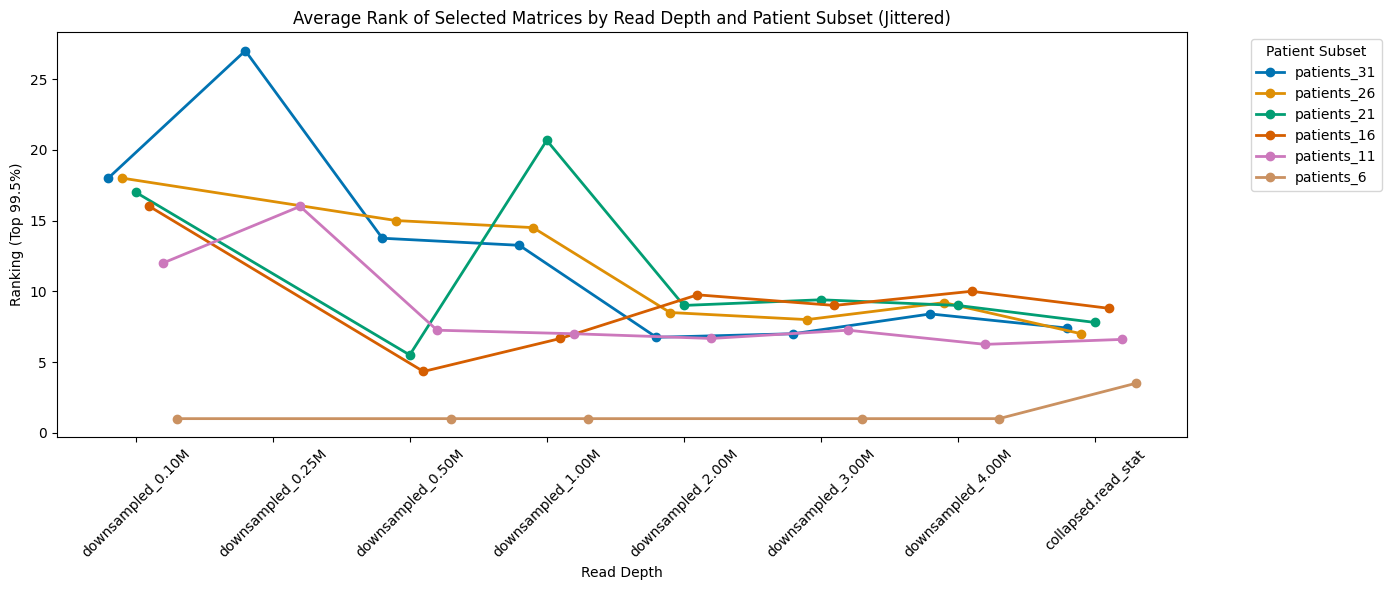

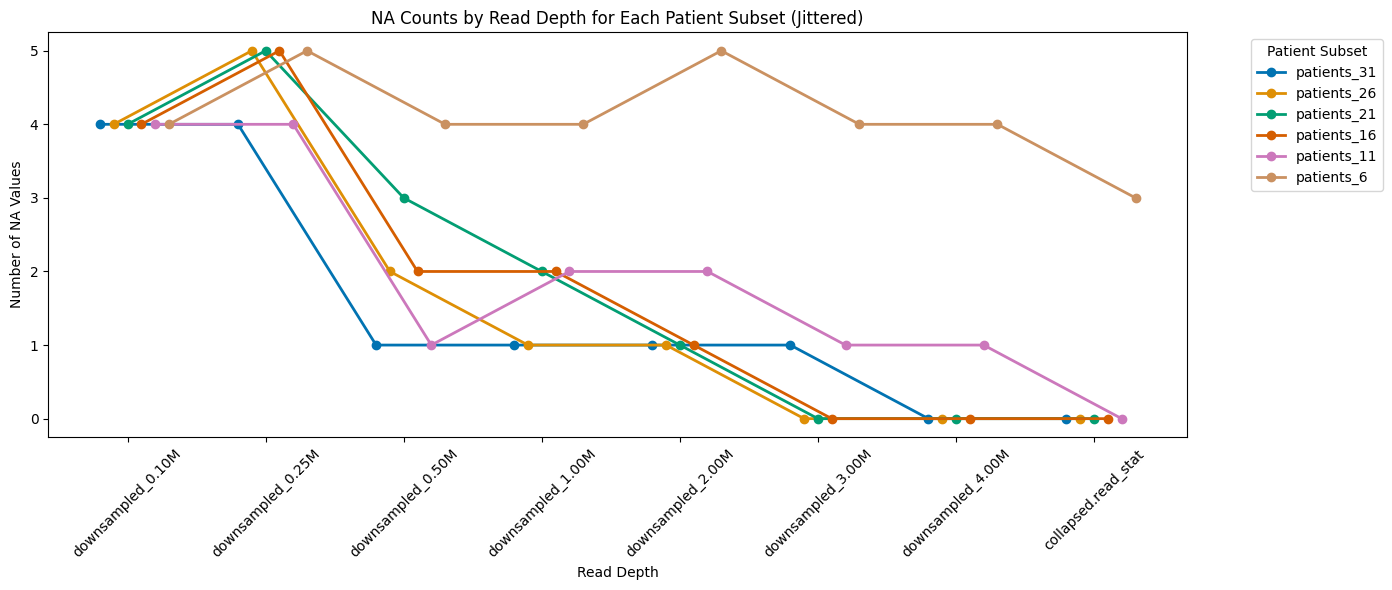

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import numpy as np
from itertools import product

# Settings
input_dir = "summary_matrices_99_5"
subset_order = ["patients_31", "patients_26", "patients_21", "patients_16", "patients_11", "patients_6"]
read_stat_order = [
    "downsampled_0.10M", "downsampled_0.25M", "downsampled_0.50M", 
    "downsampled_1.00M", "downsampled_2.00M", "downsampled_3.00M", 
    "downsampled_4.00M", "collapsed.read_stat"
]

# === Load and melt all matrices ===
all_melted = []

for filepath in glob.glob(os.path.join(input_dir, "*.tsv")):
    key = os.path.basename(filepath).replace(".tsv", "").replace("__", "|")
    sample, gene, source_type = key.split("|")
    
    df = pd.read_csv(filepath, sep="\t", index_col=0)
    df = df.loc[df.index.isin(read_stat_order)]
    df = df.reindex(index=read_stat_order, columns=subset_order)

    melted = df.reset_index().melt(id_vars="read_stat_path", var_name="patient_subset", value_name="rank")
    melted["Sample"] = sample
    melted["Gene"] = gene
    melted["Source_Type"] = source_type
    melted["Label"] = f"{sample}\n{gene}\n{source_type}"
    all_melted.append(melted)

# === Combine and filter melted data ===
plot_df = pd.concat(all_melted, ignore_index=True)
plot_df = plot_df[plot_df["Label"].isin(matrices_to_keep)]

# === Ensure full (read_stat × patient_subset) per Label ===
label_info = plot_df[["Sample", "Gene", "Source_Type", "Label"]].drop_duplicates()

full_combos = pd.DataFrame(
    list(product(matrices_to_keep, read_stat_order, subset_order)),
    columns=["Label", "read_stat_path", "patient_subset"]
)

# Merge to get sample, gene, source_type
full_combos = full_combos.merge(label_info, on="Label", how="left")

# Merge with actual data
plot_df = full_combos.merge(
    plot_df[["read_stat_path", "patient_subset", "Label", "rank"]],
    on=["read_stat_path", "patient_subset", "Label"],
    how="left"
)

# === Aggregation: mean rank, std, NA counts ===
agg_df = plot_df.groupby(["read_stat_path", "patient_subset"]).agg(
    mean_rank=("rank", "mean"),
    std_rank=("rank", "std"),
    na_count=("rank", lambda x: x.isna().sum())
).reset_index()

# Ensure order
agg_df["read_stat_path"] = pd.Categorical(agg_df["read_stat_path"], categories=read_stat_order, ordered=True)
agg_df["patient_subset"] = pd.Categorical(agg_df["patient_subset"], categories=subset_order, ordered=True)
agg_df = agg_df.sort_values(["patient_subset", "read_stat_path"])

# === Jittered x-coordinates for both plots ===
agg_df["x_numeric"] = agg_df["read_stat_path"].map({v: i for i, v in enumerate(read_stat_order)})
subset_offsets = {subset: i * 0.1 - 0.2 for i, subset in enumerate(subset_order)}
agg_df["x_jittered"] = agg_df.apply(lambda row: row["x_numeric"] + subset_offsets[row["patient_subset"]], axis=1)

# === Plot 1: Jittered Line Plot (No Error Bars, Gapped Lines Fixed) ===
palette = sns.color_palette("colorblind", n_colors=len(subset_order))
color_map = dict(zip(subset_order, palette))

fig, ax1 = plt.subplots(figsize=(14, 6))

for subset in subset_order:
    subset_df = agg_df[agg_df["patient_subset"] == subset].copy()
    subset_df = subset_df.dropna(subset=["mean_rank"]).sort_values("x_jittered")

    ax1.plot(
        subset_df["x_jittered"],
        subset_df["mean_rank"],
        label=subset,
        color=color_map[subset],
        marker="o",
        linestyle="-",
        linewidth=2
    )

ax1.set_xticks(range(len(read_stat_order)))
ax1.set_xticklabels(read_stat_order, rotation=45)
ax1.set_xlabel("Read Depth")
ax1.set_ylabel("Ranking (Top 99.5%)")
ax1.set_title("Average Rank of Selected Matrices by Read Depth and Patient Subset (Jittered)")
ax1.legend(title="Patient Subset", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig("99_5_downsampling_showing_rank_keeping_minor_isoforms_using_6_patients_pos_controls.pdf")
plt.show()
plt.close()

# === Plot 2: Jittered NA Count Line Plot ===
fig, ax2 = plt.subplots(figsize=(14, 6))

for subset in subset_order:
    subset_df = agg_df[agg_df["patient_subset"] == subset].copy()
    subset_df = subset_df.sort_values("x_jittered")

    ax2.plot(
        subset_df["x_jittered"],
        subset_df["na_count"],
        label=subset,
        color=color_map[subset],
        marker="o",
        linewidth=2
    )

ax2.set_xticks(range(len(read_stat_order)))
ax2.set_xticklabels(read_stat_order, rotation=45)
ax2.set_xlabel("Read Depth")
ax2.set_ylabel("Number of NA Values")
ax2.set_title("NA Counts by Read Depth for Each Patient Subset (Jittered)")
ax2.legend(title="Patient Subset", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig("99_5_downsampling_showing_NA_keeping_minor_isoforms_using_6_patients_pos_controls.pdf")
plt.show()
plt.close()


#### Using known transcript alterations plus HARS1

In [6]:
matrices_to_keep = [
       'UDN212054\nDND1_HARS1\nCyclo_Allelic_Imbalance',
       'UDN212054\nDND1_HARS1\nCyclo_GOE',
       'UDN212054\nHARS1\nNonyclo_Allelic_Imbalance',
       'UDN212054\nHARS1\nNoncyclo_LOE',
       'UDN212054\nHARS1\nNMD_rare_steady_state_transcript',
       'UDN633333\nMFN2\nNMD_rare_steady_state_transcript',
       'UDN687128\nVTA1\nNoncyclo_LOE',
       'UDN687128\nVTA1\nNonyclo_Allelic_Imbalance',
       'UDN215640\nPB.97189.156\nNoncyclo_GOE',
       'UDN215640\nPB.97189.156\nCyclo_GOE']

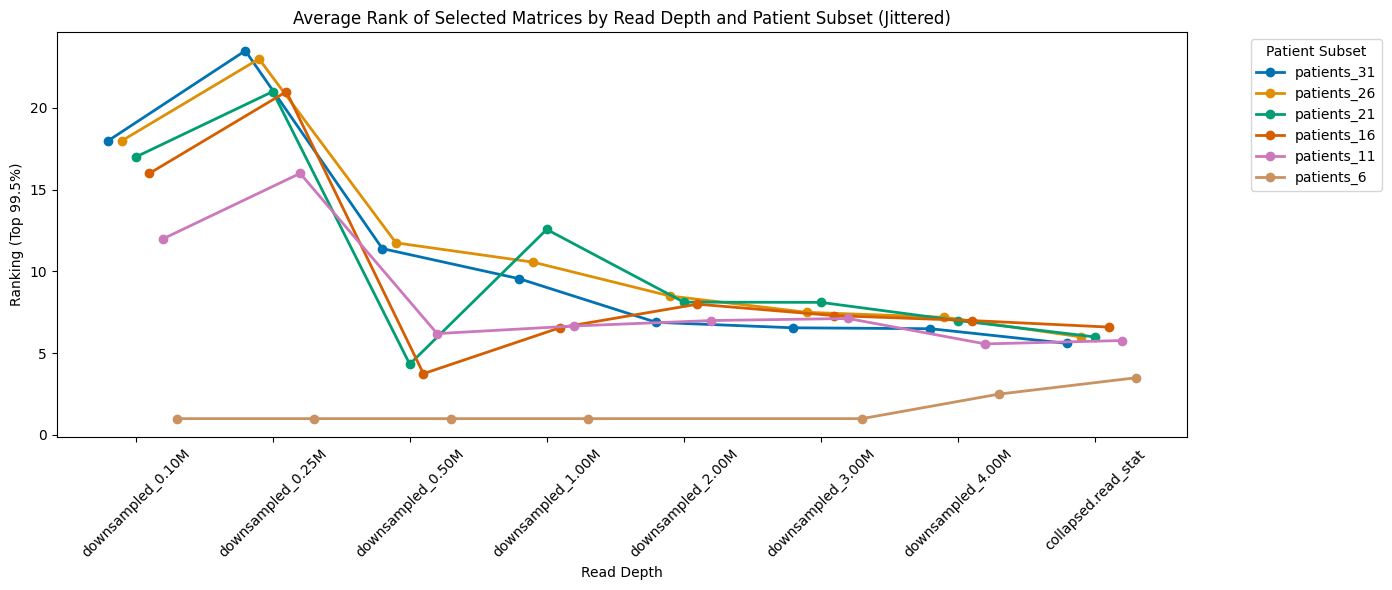

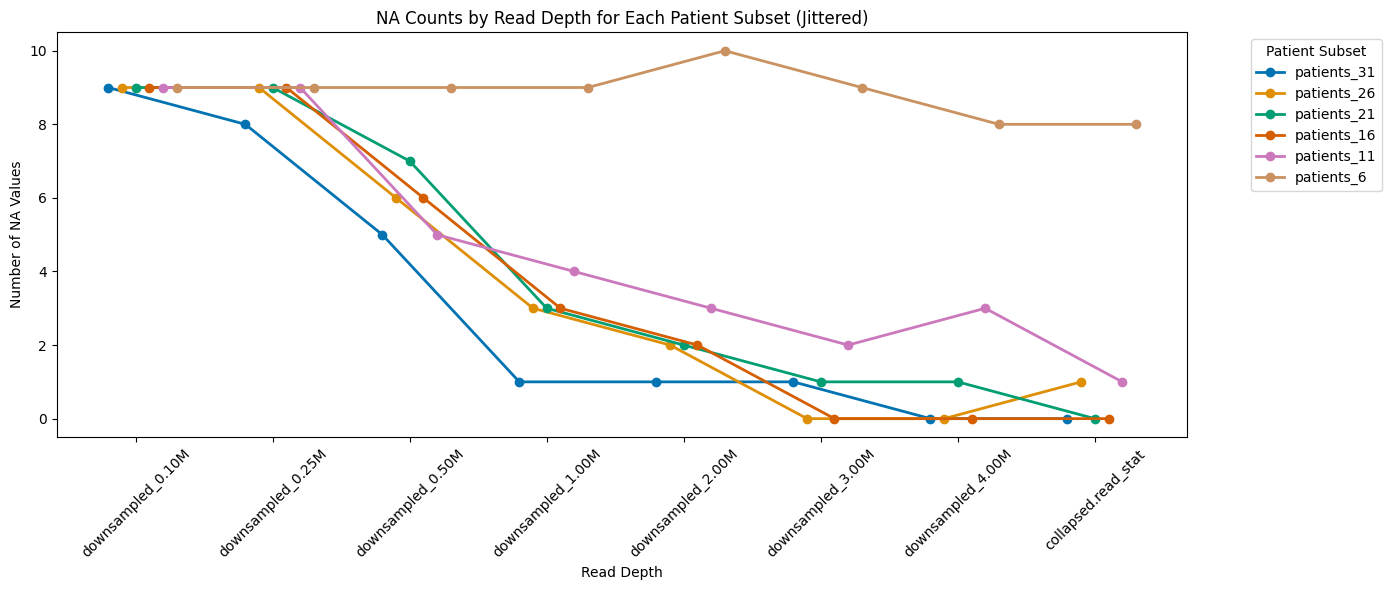

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import numpy as np
from itertools import product

# Settings
input_dir = "summary_matrices_99_5"
subset_order = ["patients_31", "patients_26", "patients_21", "patients_16", "patients_11", "patients_6"]
read_stat_order = [
    "downsampled_0.10M", "downsampled_0.25M", "downsampled_0.50M", 
    "downsampled_1.00M", "downsampled_2.00M", "downsampled_3.00M", 
    "downsampled_4.00M", "collapsed.read_stat"
]

# === Load and melt all matrices ===
all_melted = []

for filepath in glob.glob(os.path.join(input_dir, "*.tsv")):
    key = os.path.basename(filepath).replace(".tsv", "").replace("__", "|")
    sample, gene, source_type = key.split("|")
    
    df = pd.read_csv(filepath, sep="\t", index_col=0)
    df = df.loc[df.index.isin(read_stat_order)]
    df = df.reindex(index=read_stat_order, columns=subset_order)

    melted = df.reset_index().melt(id_vars="read_stat_path", var_name="patient_subset", value_name="rank")
    melted["Sample"] = sample
    melted["Gene"] = gene
    melted["Source_Type"] = source_type
    melted["Label"] = f"{sample}\n{gene}\n{source_type}"
    all_melted.append(melted)

# === Combine and filter melted data ===
plot_df = pd.concat(all_melted, ignore_index=True)
plot_df = plot_df[plot_df["Label"].isin(matrices_to_keep)]

# === Ensure full (read_stat × patient_subset) per Label ===
label_info = plot_df[["Sample", "Gene", "Source_Type", "Label"]].drop_duplicates()

full_combos = pd.DataFrame(
    list(product(matrices_to_keep, read_stat_order, subset_order)),
    columns=["Label", "read_stat_path", "patient_subset"]
)

# Merge to get sample, gene, source_type
full_combos = full_combos.merge(label_info, on="Label", how="left")

# Merge with actual data
plot_df = full_combos.merge(
    plot_df[["read_stat_path", "patient_subset", "Label", "rank"]],
    on=["read_stat_path", "patient_subset", "Label"],
    how="left"
)

# === Aggregation: mean rank, std, NA counts ===
agg_df = plot_df.groupby(["read_stat_path", "patient_subset"]).agg(
    mean_rank=("rank", "mean"),
    std_rank=("rank", "std"),
    na_count=("rank", lambda x: x.isna().sum())
).reset_index()

# Ensure order
agg_df["read_stat_path"] = pd.Categorical(agg_df["read_stat_path"], categories=read_stat_order, ordered=True)
agg_df["patient_subset"] = pd.Categorical(agg_df["patient_subset"], categories=subset_order, ordered=True)
agg_df = agg_df.sort_values(["patient_subset", "read_stat_path"])

# === Jittered x-coordinates for both plots ===
agg_df["x_numeric"] = agg_df["read_stat_path"].map({v: i for i, v in enumerate(read_stat_order)})
subset_offsets = {subset: i * 0.1 - 0.2 for i, subset in enumerate(subset_order)}
agg_df["x_jittered"] = agg_df.apply(lambda row: row["x_numeric"] + subset_offsets[row["patient_subset"]], axis=1)

# === Plot 1: Jittered Line Plot (No Error Bars, Gapped Lines Fixed) ===
palette = sns.color_palette("colorblind", n_colors=len(subset_order))
color_map = dict(zip(subset_order, palette))

fig, ax1 = plt.subplots(figsize=(14, 6))

for subset in subset_order:
    subset_df = agg_df[agg_df["patient_subset"] == subset].copy()
    subset_df = subset_df.dropna(subset=["mean_rank"]).sort_values("x_jittered")

    ax1.plot(
        subset_df["x_jittered"],
        subset_df["mean_rank"],
        label=subset,
        color=color_map[subset],
        marker="o",
        linestyle="-",
        linewidth=2
    )

ax1.set_xticks(range(len(read_stat_order)))
ax1.set_xticklabels(read_stat_order, rotation=45)
ax1.set_xlabel("Read Depth")
ax1.set_ylabel("Ranking (Top 99.5%)")
ax1.set_title("Average Rank of Selected Matrices by Read Depth and Patient Subset (Jittered)")
ax1.legend(title="Patient Subset", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig("99_5_downsampling_showing_rank_keeping_minor_isoforms_using_6_patients_ALL.pdf")
plt.show()
plt.close()

# === Plot 2: Jittered NA Count Line Plot ===
fig, ax2 = plt.subplots(figsize=(14, 6))

for subset in subset_order:
    subset_df = agg_df[agg_df["patient_subset"] == subset].copy()
    subset_df = subset_df.sort_values("x_jittered")

    ax2.plot(
        subset_df["x_jittered"],
        subset_df["na_count"],
        label=subset,
        color=color_map[subset],
        marker="o",
        linewidth=2
    )

ax2.set_xticks(range(len(read_stat_order)))
ax2.set_xticklabels(read_stat_order, rotation=45)
ax2.set_xlabel("Read Depth")
ax2.set_ylabel("Number of NA Values")
ax2.set_title("NA Counts by Read Depth for Each Patient Subset (Jittered)")
ax2.legend(title="Patient Subset", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig("99_5_downsampling_showing_NA_keeping_minor_isoforms_using_6_patients_ALL.pdf")
plt.show()
plt.close()
